# LITS Dataset Visualization

This notebook visualizes the LITS (Liver Tumor Segmentation) CT volumes and their corresponding segmentation masks.

In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Try to import ipywidgets for interactive features
try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("Note: ipywidgets not installed. Interactive features will be disabled.")
    print("Install with: pip install ipywidgets")

In [2]:
# Define paths
data_dir = Path(r'c:\Users\cahel\Desktop\Med3Tab-PFN\data\LITS\media\nas\01_Datasets\CT\LITS\Training Batch 1')

# Get list of volume files
volume_files = sorted(list(data_dir.glob('volume-*.nii')))
print(f"Found {len(volume_files)} volumes")

# Display first few filenames
for i, vol in enumerate(volume_files[:5]):
    print(f"{i}: {vol.name}")

Found 28 volumes
0: volume-0.nii
1: volume-1.nii
2: volume-10.nii
3: volume-11.nii
4: volume-12.nii


In [3]:
def load_volume(volume_path):
    """Load a NIfTI volume and return the data array."""
    nii = nib.load(str(volume_path))
    data = nii.get_fdata()
    return data, nii

def load_segmentation(volume_path):
    """Load the corresponding segmentation for a volume."""
    seg_path = str(volume_path).replace('volume-', 'segmentation-')
    if os.path.exists(seg_path):
        nii = nib.load(seg_path)
        return nii.get_fdata(), nii
    return None, None

def find_segmentation_slices(seg_data, axis=2, min_pixels=10):
    """
    Find slices that contain segmentation data.
    
    Parameters:
    -----------
    seg_data : ndarray
        Segmentation data
    axis : int
        Axis to check (0=sagittal, 1=coronal, 2=axial)
    min_pixels : int
        Minimum number of segmented pixels to consider a slice valid
        
    Returns:
    --------
    list of int : Slice indices that contain segmentation
    """
    if seg_data is None:
        return []
    
    slices_with_seg = []
    for i in range(seg_data.shape[axis]):
        if axis == 0:
            slice_data = seg_data[i, :, :]
        elif axis == 1:
            slice_data = seg_data[:, i, :]
        else:
            slice_data = seg_data[:, :, i]
        
        if np.sum(slice_data > 0) >= min_pixels:
            slices_with_seg.append(i)
    
    return slices_with_seg

In [ ]:
def orient_axial_slice(slice_data):
    """Rotate slices so the patient bed runs horizontally through the center."""
    if slice_data is None:
        return None
    # Single 90° counter-clockwise rotation matches scanner orientation (bed centered horizontally)
    return np.rot90(slice_data, k=1)


In [ ]:
def visualize_volume(volume_idx=0, slice_idx=None, axis=2, auto_find_seg=True):
    """
    Visualize a volume and its segmentation.
    
    Parameters:
    -----------
    volume_idx : int
        Index of the volume to visualize
    slice_idx : int or None
        Slice index to display. If None, uses middle slice or finds slice with segmentation.
    axis : int
        Axis along which to slice (0=sagittal, 1=coronal, 2=axial)
    auto_find_seg : bool
        If True, automatically find a slice with segmentation data
    """
    volume_path = volume_files[volume_idx]
    print(f"Loading: {volume_path.name}")
    
    # Load volume and segmentation
    volume_data, volume_nii = load_volume(volume_path)
    seg_data, seg_nii = load_segmentation(volume_path)
    
    # Print volume information
    print(f"Volume shape: {volume_data.shape}")
    print(f"Volume range: [{volume_data.min():.1f}, {volume_data.max():.1f}]")
    print(f"Spacing: {volume_nii.header.get_zooms()[:3]}")
    
    if seg_data is not None:
        unique_labels = np.unique(seg_data)
        print(f"Segmentation labels: {unique_labels}")
        
        # Find slices with segmentation
        seg_slices = find_segmentation_slices(seg_data, axis=axis)
        if len(seg_slices) > 0:
            print(f"Slices with segmentation: {len(seg_slices)} slices")
            print(f"  Range: {min(seg_slices)} to {max(seg_slices)}")
            print(f"  Middle slice with seg: {seg_slices[len(seg_slices)//2]}")
            
            # Auto-select a slice with segmentation if requested
            if slice_idx is None and auto_find_seg:
                slice_idx = seg_slices[len(seg_slices)//2]
                print(f"Auto-selected slice {slice_idx} (contains segmentation)")
        else:
            print("WARNING: No segmentation found in this volume!")
    
    # Select middle slice if not specified
    if slice_idx is None:
        slice_idx = volume_data.shape[axis] // 2
        print(f"Using middle slice: {slice_idx}")
    
    # Extract slices
    if axis == 0:
        vol_slice = volume_data[slice_idx, :, :]
        seg_slice = seg_data[slice_idx, :, :] if seg_data is not None else None
    elif axis == 1:
        vol_slice = volume_data[:, slice_idx, :]
        seg_slice = seg_data[:, slice_idx, :] if seg_data is not None else None
    else:  # axis == 2 (axial)
        vol_slice = volume_data[:, :, slice_idx]
        seg_slice = seg_data[:, :, slice_idx] if seg_data is not None else None
    
    if axis == 2:
        vol_slice = orient_axial_slice(vol_slice)
        if seg_slice is not None:
            seg_slice = orient_axial_slice(seg_slice)
        print("Applied axial slice orientation (90° CCW)")
    
    if seg_slice is not None:
        # Count segmented pixels in this slice
        seg_pixels = np.sum(seg_slice > 0)
        print(f"Segmented pixels in this slice: {seg_pixels}")
    
    # Create visualization
    if seg_data is not None:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Volume only
        axes[0].imshow(vol_slice, cmap='gray', aspect='auto')
        axes[0].set_title(f'CT Volume - Slice {slice_idx}')
        axes[0].axis('off')
        
        # Segmentation only
        im = axes[1].imshow(seg_slice, cmap='jet', aspect='auto', vmin=0, vmax=2)
        axes[1].set_title(f'Segmentation Mask\n({seg_pixels} pixels)')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1], fraction=0.046)
        
        # Overlay
        axes[2].imshow(vol_slice, cmap='gray', aspect='auto')
        # Create a masked overlay where segmentation > 0
        mask = seg_slice > 0
        if np.any(mask):
            overlay = np.ma.masked_where(~mask, seg_slice)
            axes[2].imshow(overlay, cmap='jet', alpha=0.5, aspect='auto', vmin=0, vmax=2)
        axes[2].set_title('Overlay')
        axes[2].axis('off')
        
    else:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(vol_slice, cmap='gray', aspect='auto')
        ax.set_title(f'CT Volume - Slice {slice_idx}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 2. Dataset Overview

Let's create a summary of all volumes and their segmentation statistics:

In [5]:
# Create summary table of all volumes
import pandas as pd

def create_dataset_summary():
    """Create a summary table of all volumes and their segmentations."""
    summary_data = []
    
    for idx, volume_path in enumerate(volume_files):
        try:
            volume_data, _ = load_volume(volume_path)
            seg_data, _ = load_segmentation(volume_path)
            
            row = {
                'Index': idx,
                'Volume': volume_path.name,
                'Shape': volume_data.shape,
                'Has_Seg': seg_data is not None
            }
            
            if seg_data is not None:
                # Count segmentation pixels
                liver_pixels = np.sum(seg_data == 1)
                tumor_pixels = np.sum(seg_data == 2)
                total_seg_pixels = liver_pixels + tumor_pixels
                
                # Find slice range with segmentation
                seg_slices = find_segmentation_slices(seg_data, axis=2)
                
                row['Liver_Pixels'] = liver_pixels
                row['Tumor_Pixels'] = tumor_pixels
                row['Total_Seg_Pixels'] = total_seg_pixels
                row['Num_Seg_Slices'] = len(seg_slices)
                row['Seg_Slice_Range'] = f"{min(seg_slices)}-{max(seg_slices)}" if seg_slices else "None"
            else:
                row['Liver_Pixels'] = 0
                row['Tumor_Pixels'] = 0
                row['Total_Seg_Pixels'] = 0
                row['Num_Seg_Slices'] = 0
                row['Seg_Slice_Range'] = "None"
            
            summary_data.append(row)
        except Exception as e:
            print(f"Error processing {volume_path.name}: {e}")
    
    df = pd.DataFrame(summary_data)
    return df

# Create and display summary
summary_df = create_dataset_summary()
print(f"\nDataset Summary ({len(volume_files)} volumes):")
print("="*80)
display(summary_df)

# Show statistics
print("\n" + "="*80)
print(f"Total volumes with segmentation: {summary_df['Has_Seg'].sum()}")
print(f"Total volumes without segmentation: {(~summary_df['Has_Seg']).sum()}")
if summary_df['Has_Seg'].any():
    print(f"\nSegmentation Statistics (for volumes with segmentation):")
    seg_df = summary_df[summary_df['Has_Seg']]
    print(f"  Average liver pixels: {seg_df['Liver_Pixels'].mean():,.0f}")
    print(f"  Average tumor pixels: {seg_df['Tumor_Pixels'].mean():,.0f}")
    print(f"  Average segmented slices: {seg_df['Num_Seg_Slices'].mean():.1f}")
print("="*80)


Dataset Summary (28 volumes):


,Index,Volume,Shape,Has_Seg,Liver_Pixels,Tumor_Pixels,Total_Seg_Pixels,Num_Seg_Slices,Seg_Slice_Range
0,0,volume-0.nii,"(512, 512, 75)",True,550036,2591,552627,29,45-73
1,1,volume-1.nii,"(512, 512, 123)",True,643779,7194,650973,28,46-73
2,2,volume-10.nii,"(512, 512, 501)",True,2857366,24310,2881676,181,295-475
3,3,volume-11.nii,"(512, 512, 466)",True,3253446,10549,3263995,167,272-438
4,4,volume-12.nii,"(512, 512, 455)",True,4205057,790,4205847,189,265-453
5,5,volume-13.nii,"(512, 512, 605)",True,1876901,23651,1900552,141,273-413
6,6,volume-14.nii,"(512, 512, 588)",True,3041924,2612,3044536,139,260-398
7,7,volume-15.nii,"(512, 512, 565)",True,3236299,875,3237174,133,240-372
8,8,volume-16.nii,"(512, 512, 689)",True,3165361,373122,3538483,187,267-453
9,9,volume-17.nii,"(512, 512, 826)",True,3582734,37676,3620410,198,328-525



Total volumes with segmentation: 28
Total volumes without segmentation: 0

Segmentation Statistics (for volumes with segmentation):
  Average liver pixels: 2,649,770
  Average tumor pixels: 88,729
  Average segmented slices: 161.1


In [6]:
# Interactive visualization with sliders (requires ipywidgets)
def interactive_viewer(volume_idx=0):
    """Create an interactive viewer with slice slider."""
    if not HAS_WIDGETS:
        print("Interactive viewer requires ipywidgets.")
        print("Install with: pip install ipywidgets")
        print("\nAlternatively, use visualize_volume() function directly.")
        print("Example: visualize_volume(volume_idx=0, slice_idx=50, axis=2)")
        return
    
    volume_path = volume_files[volume_idx]
    volume_data, _ = load_volume(volume_path)
    
    # Create slice slider
    slice_slider = widgets.IntSlider(
        value=volume_data.shape[2] // 2,
        min=0,
        max=volume_data.shape[2] - 1,
        step=1,
        description='Slice:',
        continuous_update=False
    )
    
    # Create axis selector
    axis_selector = widgets.Dropdown(
        options=[('Axial', 2), ('Coronal', 1), ('Sagittal', 0)],
        value=2,
        description='View:'
    )
    
    def update_view(slice_idx, axis):
        # Update slider range based on axis
        slice_slider.max = volume_data.shape[axis] - 1
        if slice_idx > slice_slider.max:
            slice_idx = slice_slider.max // 2
        visualize_volume(volume_idx, slice_idx, axis)
    
    return widgets.interactive(update_view, slice_idx=slice_slider, axis=axis_selector)

## Understanding the Dataset

First, let's see which slices actually contain segmentation data:

## 3. Single Slice Visualization

Visualize single slices with automatic segmentation detection:

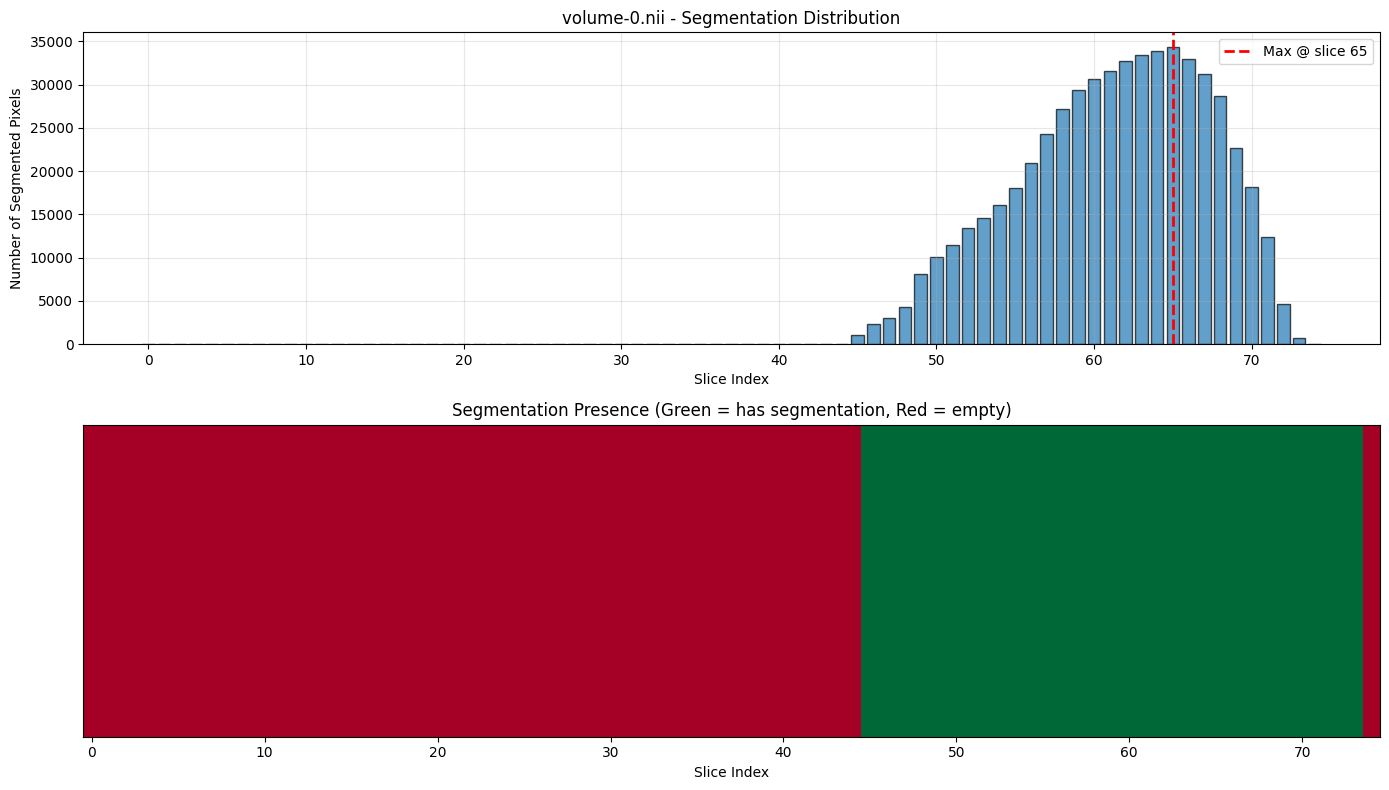


Segmentation present in 29/75 slices
Range: slices 45 to 73
Recommended slices to view: [45, 50, 55, 60, 65, 70]


In [7]:
# Helper: Visualize segmentation distribution across slices
def plot_segmentation_distribution(volume_idx=0, axis=2):
    """Plot which slices contain segmentation data."""
    volume_path = volume_files[volume_idx]
    volume_data, _ = load_volume(volume_path)
    seg_data, _ = load_segmentation(volume_path)
    
    if seg_data is None:
        print("No segmentation data found!")
        return
    
    # Count segmented pixels per slice
    num_slices = seg_data.shape[axis]
    seg_counts = []
    
    for i in range(num_slices):
        if axis == 0:
            slice_data = seg_data[i, :, :]
        elif axis == 1:
            slice_data = seg_data[:, i, :]
        else:
            slice_data = seg_data[:, :, i]
        
        seg_counts.append(np.sum(slice_data > 0))
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Bar plot of segmentation counts
    ax1.bar(range(num_slices), seg_counts, alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Slice Index')
    ax1.set_ylabel('Number of Segmented Pixels')
    ax1.set_title(f'{volume_path.name} - Segmentation Distribution')
    ax1.grid(True, alpha=0.3)
    
    # Heatmap view
    seg_presence = np.array(seg_counts) > 0
    ax2.imshow([seg_presence], cmap='RdYlGn', aspect='auto', interpolation='nearest')
    ax2.set_xlabel('Slice Index')
    ax2.set_yticks([])
    ax2.set_title('Segmentation Presence (Green = has segmentation, Red = empty)')
    
    # Mark slices with most segmentation
    if len(seg_counts) > 0:
        max_idx = np.argmax(seg_counts)
        ax1.axvline(x=max_idx, color='red', linestyle='--', linewidth=2, 
                   label=f'Max @ slice {max_idx}')
        ax1.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    seg_slices = [i for i, count in enumerate(seg_counts) if count > 0]
    if seg_slices:
        print(f"\nSegmentation present in {len(seg_slices)}/{num_slices} slices")
        print(f"Range: slices {min(seg_slices)} to {max(seg_slices)}")
        print(f"Recommended slices to view: {seg_slices[::max(1, len(seg_slices)//5)]}")

# Show distribution for first volume
plot_segmentation_distribution(volume_idx=0, axis=2)

Loading: volume-0.nii
Volume shape: (512, 512, 75)
Volume range: [-3024.0, 1410.0]
Spacing: (np.float32(0.703125), np.float32(0.703125), np.float32(5.0))
Segmentation labels: [0. 1. 2.]
Slices with segmentation: 29 slices
  Range: 45 to 73
  Middle slice with seg: 59
Auto-selected slice 59 (contains segmentation)
Segmented pixels in this slice: 29401


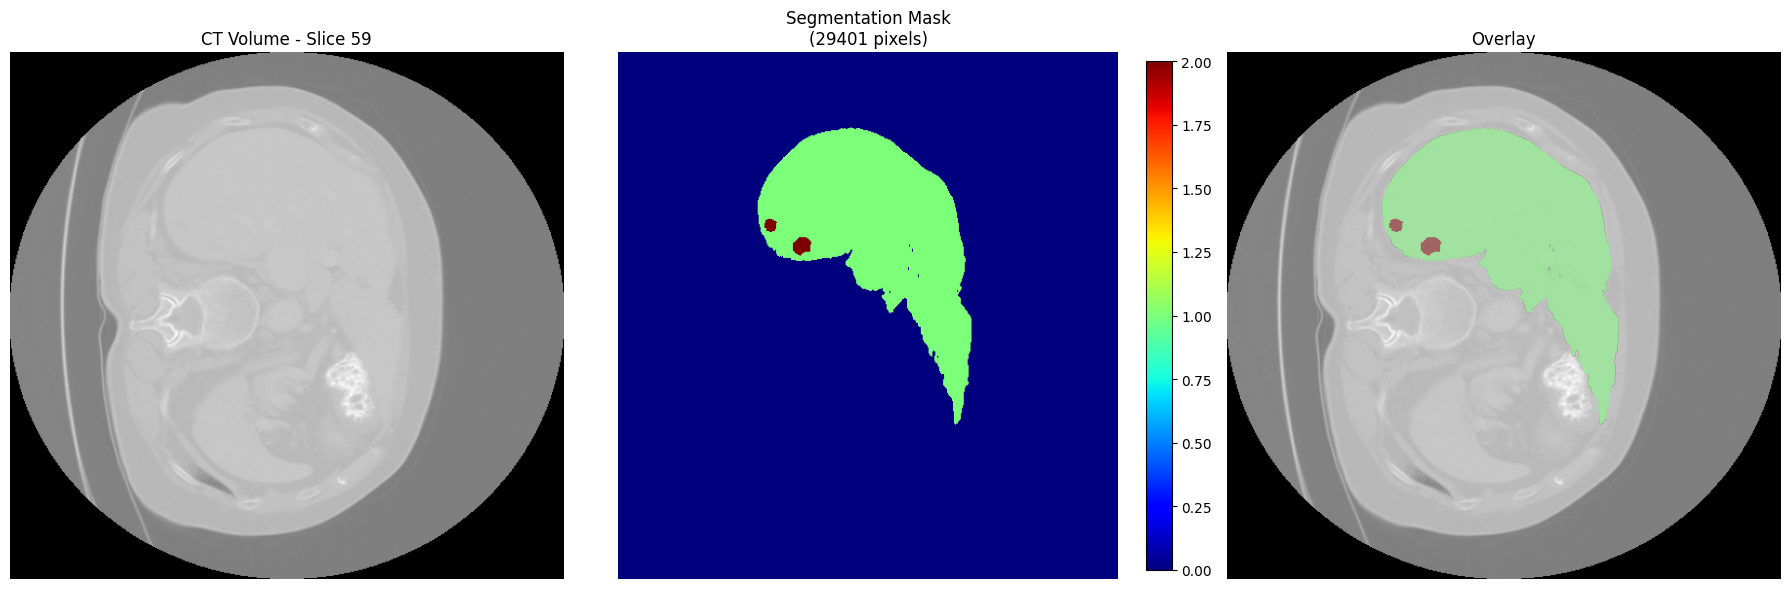

In [8]:
# Visualize first volume (automatically finds slice with segmentation)
visualize_volume(volume_idx=0, axis=2, auto_find_seg=True)

## Manual Exploration (No ipywidgets needed)

If ipywidgets is not available, you can manually explore volumes:

Showing 9 slices with segmentation


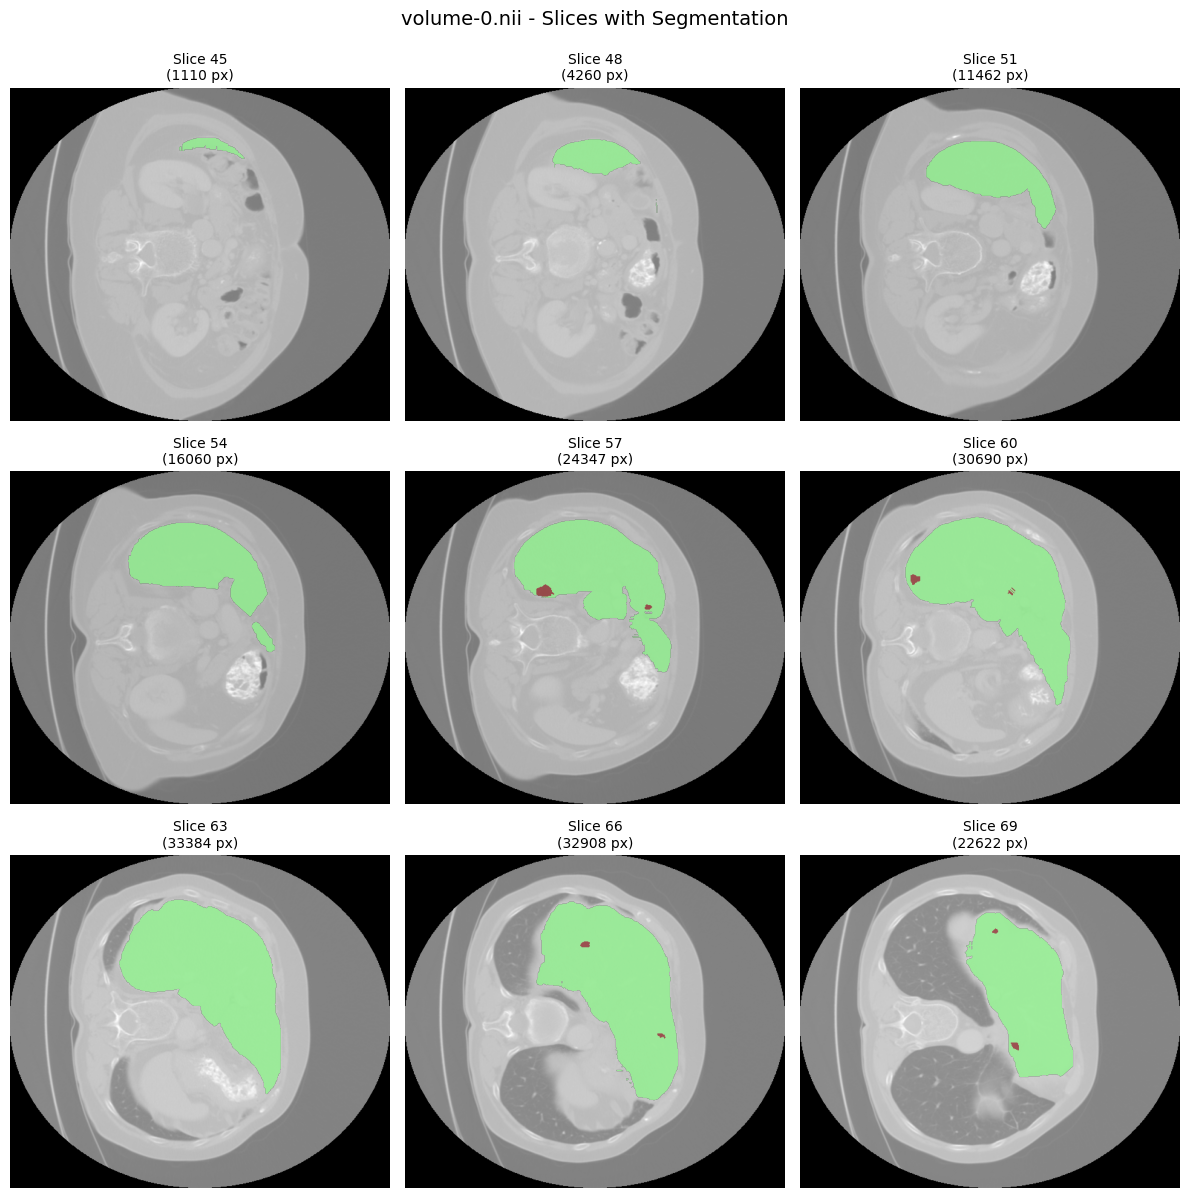

In [ ]:
# View multiple slices in a grid
def view_multiple_slices(volume_idx=0, num_slices=9, axis=2, only_with_seg=True):
    """
    Display multiple slices from a volume in a grid.
    
    Parameters:
    -----------
    volume_idx : int
        Index of the volume
    num_slices : int
        Number of slices to display
    axis : int
        Axis to slice along
    only_with_seg : bool
        If True, only show slices that contain segmentation
    """
    volume_path = volume_files[volume_idx]
    volume_data, _ = load_volume(volume_path)
    seg_data, _ = load_segmentation(volume_path)
    
    depth = volume_data.shape[axis]
    
    # Determine which slices to show
    if only_with_seg and seg_data is not None:
        seg_slices = find_segmentation_slices(seg_data, axis=axis)
        if len(seg_slices) == 0:
            print("No segmentation found! Showing evenly spaced slices instead.")
            slice_indices = np.linspace(depth//4, 3*depth//4, num_slices, dtype=int)
        else:
            # Select evenly spaced slices from those with segmentation
            if len(seg_slices) <= num_slices:
                slice_indices = seg_slices
            else:
                step = max(1, len(seg_slices) // num_slices)
                slice_indices = seg_slices[::step][:num_slices]
            print(f"Showing {len(slice_indices)} slices with segmentation")
    else:
        slice_indices = np.linspace(depth//4, 3*depth//4, num_slices, dtype=int)
    
    num_slices = len(slice_indices)
    rows = int(np.ceil(np.sqrt(num_slices)))
    cols = int(np.ceil(num_slices / rows))
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten() if num_slices > 1 else [axes]
    
    for idx, slice_idx in enumerate(slice_indices):
        if axis == 0:
            vol_slice = volume_data[slice_idx, :, :]
            seg_slice = seg_data[slice_idx, :, :] if seg_data is not None else None
        elif axis == 1:
            vol_slice = volume_data[:, slice_idx, :]
            seg_slice = seg_data[:, slice_idx, :] if seg_data is not None else None
        else:
            vol_slice = volume_data[:, :, slice_idx]
            seg_slice = seg_data[:, :, slice_idx] if seg_data is not None else None
        
        if axis == 2:
            vol_slice = orient_axial_slice(vol_slice)
            if seg_slice is not None:
                seg_slice = orient_axial_slice(seg_slice)
        
        axes[idx].imshow(vol_slice, cmap='gray', aspect='auto')
        if seg_slice is not None:
            mask = seg_slice > 0
            if np.any(mask):
                overlay = np.ma.masked_where(~mask, seg_slice)
                axes[idx].imshow(overlay, cmap='jet', alpha=0.6, aspect='auto', vmin=0, vmax=2)
                seg_count = np.sum(mask)
                axes[idx].set_title(f'Slice {slice_idx}\n({seg_count} px)', fontsize=10)
            else:
                axes[idx].set_title(f'Slice {slice_idx}', fontsize=10)
        else:
            axes[idx].set_title(f'Slice {slice_idx}', fontsize=10)
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(slice_indices), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{volume_path.name} - {"Slices with Segmentation" if only_with_seg else "Sample Slices"}', 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

# Example: View 9 slices with segmentation from the first volume
view_multiple_slices(volume_idx=0, num_slices=9, axis=2, only_with_seg=True)

In [10]:
# Interactive viewer (if ipywidgets is available)
if HAS_WIDGETS:
    # Create volume selector
    volume_selector = widgets.IntSlider(
        value=0,
        min=0,
        max=len(volume_files) - 1,
        step=1,
        description='Volume:',
        continuous_update=False
    )
    
    widgets.interact(interactive_viewer, volume_idx=volume_selector)
else:
    print("Interactive widgets not available (ipywidgets not installed)")
    print("\nYou can still visualize volumes manually using:")
    print("  visualize_volume(volume_idx=0, slice_idx=None, axis=2)")
    print("\nParameters:")
    print("  - volume_idx: index of volume (0 to {})".format(len(volume_files)-1))
    print("  - slice_idx: slice number (or None for middle slice)")
    print("  - axis: 0=sagittal, 1=coronal, 2=axial")
    print("\nExample:")
    print("  visualize_volume(volume_idx=1, slice_idx=100, axis=2)")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Volume:', max=27), Output()), _…

def compare_volumes(indices=[0, 1, 2], slice_fraction=0.5, axis=2):
    """
    Compare multiple volumes side by side.
    
    Parameters:
    -----------
    indices : list of int
        Indices of volumes to compare
    slice_fraction : float
        Fraction of volume depth to slice at (0.5 = middle)
    axis : int
        Axis along which to slice
    """
    n_volumes = len(indices)
    fig, axes = plt.subplots(2, n_volumes, figsize=(6*n_volumes, 12))
    if n_volumes == 1:
        axes = axes.reshape(-1, 1)
    
    for i, vol_idx in enumerate(indices):
        if vol_idx >= len(volume_files):
            continue
            
        volume_path = volume_files[vol_idx]
        volume_data, _ = load_volume(volume_path)
        seg_data, _ = load_segmentation(volume_path)
        
        # Calculate slice index
        slice_idx = int(volume_data.shape[axis] * slice_fraction)
        
        # Extract slices
        if axis == 0:
            vol_slice = volume_data[slice_idx, :, :]
            seg_slice = seg_data[slice_idx, :, :] if seg_data is not None else None
        elif axis == 1:
            vol_slice = volume_data[:, slice_idx, :]
            seg_slice = seg_data[:, slice_idx, :] if seg_data is not None else None
        else:
            vol_slice = volume_data[:, :, slice_idx]
            seg_slice = seg_data[:, :, slice_idx] if seg_data is not None else None
        
        # Rotate for proper orientation (bed at bottom)
        vol_slice = np.flipud(np.rot90(vol_slice.T))
        if seg_slice is not None:
            seg_slice = np.flipud(np.rot90(seg_slice.T))
        
        # Display volume
        axes[0, i].imshow(vol_slice, cmap='gray', aspect='auto')
        axes[0, i].set_title(f'{volume_path.name}\nSlice {slice_idx}')
        axes[0, i].axis('off')
        
        # Display overlay
        axes[1, i].imshow(vol_slice, cmap='gray', aspect='auto')
        if seg_slice is not None:
            mask = seg_slice > 0
            overlay = np.ma.masked_where(~mask, seg_slice)
            axes[1, i].imshow(overlay, cmap='jet', alpha=0.5, aspect='auto')
        axes[1, i].set_title('With Segmentation')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

## Volume Statistics

In [11]:
def analyze_dataset():
    """Analyze the entire LITS dataset."""
    stats = []
    
    for vol_path in volume_files:
        volume_data, vol_nii = load_volume(vol_path)
        seg_data, _ = load_segmentation(vol_path)
        
        spacing = vol_nii.header.get_zooms()[:3]
        
        stat = {
            'filename': vol_path.name,
            'shape': volume_data.shape,
            'spacing': spacing,
            'min_hu': volume_data.min(),
            'max_hu': volume_data.max(),
            'mean_hu': volume_data.mean(),
            'std_hu': volume_data.std()
        }
        
        if seg_data is not None:
            unique_labels = np.unique(seg_data)
            stat['labels'] = unique_labels.tolist()
            # Calculate tumor volume (assuming label 2 is tumor)
            if 2 in unique_labels:
                voxel_volume = np.prod(spacing)  # mm³
                tumor_voxels = np.sum(seg_data == 2)
                stat['tumor_volume_mm3'] = tumor_voxels * voxel_volume
                stat['tumor_volume_ml'] = stat['tumor_volume_mm3'] / 1000
        
        stats.append(stat)
    
    return stats

# Analyze dataset
dataset_stats = analyze_dataset()

# Display summary
print(f"Dataset Summary:")
print(f"Total volumes: {len(dataset_stats)}")
print("\nFirst 5 volumes:")
for stat in dataset_stats[:5]:
    print(f"\n{stat['filename']}:")
    print(f"  Shape: {stat['shape']}")
    print(f"  Spacing: {stat['spacing']}")
    print(f"  HU range: [{stat['min_hu']:.1f}, {stat['max_hu']:.1f}]")
    if 'tumor_volume_ml' in stat:
        print(f"  Tumor volume: {stat['tumor_volume_ml']:.2f} ml")

Dataset Summary:
Total volumes: 28

First 5 volumes:

volume-0.nii:
  Shape: (512, 512, 75)
  Spacing: (np.float32(0.703125), np.float32(0.703125), np.float32(5.0))
  HU range: [-3024.0, 1410.0]
  Tumor volume: 6.40 ml

volume-1.nii:
  Shape: (512, 512, 123)
  Spacing: (np.float32(0.675781), np.float32(0.675781), np.float32(5.0))
  HU range: [-3024.0, 3071.0]
  Tumor volume: 16.43 ml

volume-10.nii:
  Shape: (512, 512, 501)
  Spacing: (np.float32(0.76953125), np.float32(0.76953125), np.float32(1.0))
  HU range: [-1024.0, 1602.0]
  Tumor volume: 14.40 ml

volume-11.nii:
  Shape: (512, 512, 466)
  Spacing: (np.float32(0.671875), np.float32(0.671875), np.float32(1.0))
  HU range: [-1024.0, 1633.0]
  Tumor volume: 4.76 ml

volume-12.nii:
  Shape: (512, 512, 455)
  Spacing: (np.float32(0.6542969), np.float32(0.6542969), np.float32(1.0))
  HU range: [-1024.0, 1547.0]
  Tumor volume: 0.34 ml
